<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Desafío 3: Modelo de lenguaje con tokenización por caracteres

**Corpus seleccionado:** *El Principito* de Antoine de Saint-Exupéry

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [ ]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.utils import pad_sequences 

In [2]:
# Leemos el archivo local de El Principito
with open('El Principito.txt', 'r', encoding='utf-8') as f:
    article_text = f.read()

# pasar todo el texto a minúscula
article_text = article_text.lower()

print(f"Longitud total del texto: {len(article_text)} caracteres")

Longitud total del texto: 80472 caracteres


In [3]:
# Veamos una muestra del texto
article_text[:1000]

'\ufeffantoine de saint - exupéry  el principito \nantoine de saint-exupéry - el principito \ntexto de dominio público.- \nedición electrónica: henry \nlibro electrónico \neste texto digital es de dominio público en ecuador por cumplirse más de 50 años de la muerte de su  autor. sin embargo no todas las leyes de copyright son iguales en los diferentes países del mundo.  infórmese de la situación de su país antes de la distribución pública de este texto. \ntodas las formas de redistribución digital o de impresión quedan autorizadas en aquellos países en el  cual este texto es de dominio público siempre que en las mismas se incluya el siguiente aviso: \n“la biblioteca virtual de la ueb” \nhttp://www.ueb.edu.ec \nwebmaster@ueb.edu.ec \necuador - noviembre 2003\nel principito \na. de saint - exupéry \na leon werth: \npido perdón a los niños por haber dedicado este libro a una persona mayor. tengo una seria  excusa: esta persona mayor es el mejor amigo que tengo en el mundo. tengo otra excu

In [4]:
# Veamos los primeros y últimos caracteres
print("Primeros 500 caracteres:")
print(article_text[:500])
print("\n---\nÚltimos 200 caracteres:")
print(article_text[-200:])

Primeros 500 caracteres:
﻿antoine de saint - exupéry  el principito 
antoine de saint-exupéry - el principito 
texto de dominio público.- 
edición electrónica: henry 
libro electrónico 
este texto digital es de dominio público en ecuador por cumplirse más de 50 años de la muerte de su  autor. sin embargo no todas las leyes de copyright son iguales en los diferentes países del mundo.  infórmese de la situación de su país antes de la distribución pública de este texto. 
todas las formas de redistribución digital o de impr

---
Últimos 200 caracteres:
niño ríe y tiene cabellos de oro y  nunca responde a sus preguntas, adivinarán en seguida quién es. ¡sean amables con él! y comuníquenme rápidamente que ha regresado. ¡no me dejen tan triste!  
fin
31


### Elegir el tamaño del contexto
Para este corpus (*El Principito*), **100 caracteres** es un buen compromiso: permite capturar oraciones típicas del libro (que suelen ser cortas y dialogadas) sin exceder la capacidad de las celdas recurrentes.

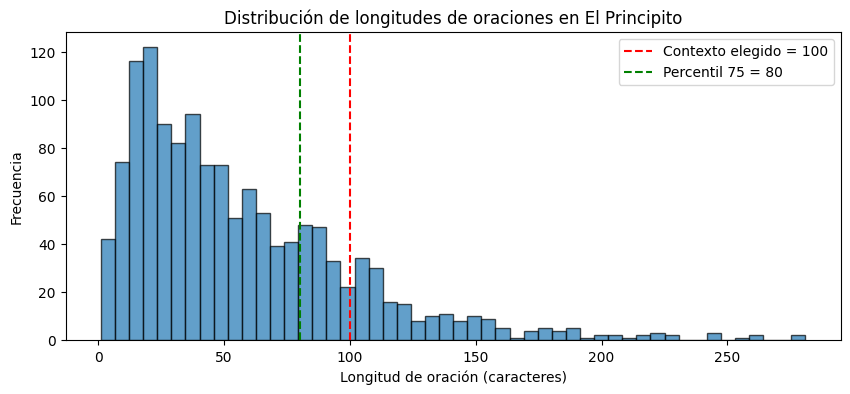

Media: 57 caracteres
Mediana: 45 caracteres
Percentil 75: 80 caracteres
Percentil 90: 111 caracteres

Con max_context_size=100 cubrimos ~85.1% de las oraciones


In [5]:
# Analicemos la distribución de longitudes de oraciones (en caracteres)
import re
oraciones = re.split(r'[.!?]+', article_text)
longitudes = [len(o.strip()) for o in oraciones if len(o.strip()) > 0]

plt.figure(figsize=(10, 4))
plt.hist(longitudes, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=100, color='red', linestyle='--', label='Contexto elegido = 100')
plt.axvline(x=np.percentile(longitudes, 75), color='green', linestyle='--', label=f'Percentil 75 = {np.percentile(longitudes, 75):.0f}')
plt.xlabel('Longitud de oración (caracteres)')
plt.ylabel('Frecuencia')
plt.title('Distribución de longitudes de oraciones en El Principito')
plt.legend()
plt.show()

print(f"Media: {np.mean(longitudes):.0f} caracteres")
print(f"Mediana: {np.median(longitudes):.0f} caracteres")
print(f"Percentil 75: {np.percentile(longitudes, 75):.0f} caracteres")
print(f"Percentil 90: {np.percentile(longitudes, 90):.0f} caracteres")
print(f"\nCon max_context_size=100 cubrimos ~{100*np.mean(np.array(longitudes) <= 100):.1f}% de las oraciones")

In [6]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [8]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [9]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

63

In [10]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [11]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [12]:
tokenized_text[:1000]

[9,
 28,
 55,
 46,
 8,
 35,
 55,
 57,
 3,
 59,
 57,
 3,
 52,
 28,
 35,
 55,
 46,
 3,
 41,
 3,
 57,
 61,
 36,
 37,
 38,
 25,
 29,
 3,
 3,
 57,
 33,
 3,
 37,
 25,
 35,
 55,
 53,
 35,
 37,
 35,
 46,
 8,
 3,
 58,
 28,
 55,
 46,
 8,
 35,
 55,
 57,
 3,
 59,
 57,
 3,
 52,
 28,
 35,
 55,
 46,
 41,
 57,
 61,
 36,
 37,
 38,
 25,
 29,
 3,
 41,
 3,
 57,
 33,
 3,
 37,
 25,
 35,
 55,
 53,
 35,
 37,
 35,
 46,
 8,
 3,
 58,
 46,
 57,
 61,
 46,
 8,
 3,
 59,
 57,
 3,
 59,
 8,
 47,
 35,
 55,
 35,
 8,
 3,
 37,
 30,
 40,
 33,
 35,
 53,
 8,
 11,
 41,
 3,
 58,
 57,
 59,
 35,
 53,
 35,
 17,
 55,
 3,
 57,
 33,
 57,
 53,
 46,
 25,
 17,
 55,
 35,
 53,
 28,
 21,
 3,
 26,
 57,
 55,
 25,
 29,
 3,
 58,
 33,
 35,
 40,
 25,
 8,
 3,
 57,
 33,
 57,
 53,
 46,
 25,
 17,
 55,
 35,
 53,
 8,
 3,
 58,
 57,
 52,
 46,
 57,
 3,
 46,
 57,
 61,
 46,
 8,
 3,
 59,
 35,
 23,
 35,
 46,
 28,
 33,
 3,
 57,
 52,
 3,
 59,
 57,
 3,
 59,
 8,
 47,
 35,
 55,
 35,
 8,
 3,
 37,
 30,
 40,
 33,
 35,
 53,
 8,
 3,
 57,
 55,
 3,
 57,
 53,
 36,
 28,
 

### Organizando y estructurando el dataset

In [13]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [14]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [15]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [16]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [17]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [18]:
X.shape

(72272, 100)

In [19]:
X[0,:10]

array([ 9, 28, 55, 46,  8, 35, 55, 57,  3, 59])

In [20]:
y[0,:10]

array([28, 55, 46,  8, 35, 55, 57,  3, 59, 57])

In [21]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

## Exploración inicial: modelos con OHE (descartados)

Se exploraron inicialmente tres arquitecturas usando **One-Hot Encoding** (OHE) como representación de caracteres, con el texto sin limpiar:

| Modelo | Arquitectura | Decodificación | Resultado |
|---|---|---|---|
| **V1 - SimpleRNN** | SimpleRNN 2x256, OHE, rmsprop | Greedy (argmax) | Loops repetitivos: *"el principito el principito..."* |
| **V2 - LSTM** | LSTM 2x256, OHE, rmsprop | Sampling con temperatura | Texto no repetitivo pero incoherente |
| **V3 - GRU** | GRU 2x256, OHE, rmsprop | Sampling con temperatura | Similar a LSTM, sin mejora significativa |

**Diagnóstico de los problemas:**
1. **Texto sucio**: el .txt proviene de un PDF y contiene ruido (encabezados, números de página, múltiples espacios, guiones de diálogo, puntos suspensivos). El modelo desperdicia capacidad aprendiendo artefactos.
2. **OHE sin Embedding**: one-hot encoding no permite aprender relaciones entre caracteres similares.
3. **Argmax en V1**: siempre elige el carácter más probable → ciclos inevitables.
4. **Overfitting severo**: con 633K+ parámetros y ~80K caracteres sin limpiar, el modelo memoriza en lugar de generalizar.

**Conclusión**: se descartaron estas versiones en favor de un modelo mejorado con texto limpio, Embedding y regularización.

## Modelo final

A partir de los problemas identificados en la exploración inicial, se implementó el modelo final con las siguientes mejoras:

1. **Limpieza exhaustiva del texto**: eliminación de metadata, números de página, capítulos romanos, puntos suspensivos, guiones de diálogo, dos puntos. Normalización de espacios.
2. **Embedding entrenable** (dim=50) en lugar de OHE: permite aprender relaciones entre caracteres similares.
3. **LSTM 2×64**: `return_sequences=True` en la primera capa, `return_sequences=False` en la segunda (alineando entrenamiento e inferencia).
4. **Regularización**: Dropout(0.2) entre capas LSTM.
5. **Optimizador rmsprop** + ReduceLROnPlateau.
6. **Datos**: split por oraciones + sub-secuencias prefijo (data augmentation), contexto de 60 caracteres.

In [22]:
clean_file = 'El_Principito_limpio_v2.txt'
with open(clean_file, 'r', encoding='utf-8') as f:
    clean_text = f.read()

### Re-tokenización con texto limpio

In [ ]:
import re
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import pad_sequences

# Vocabulario y tokenización sobre el texto limpio
chars_vocab_v3 = sorted(set(clean_text))
vocab_size_v3 = len(chars_vocab_v3)

# Índices desde 1 
char2idx_v3 = {ch: i + 1 for i, ch in enumerate(chars_vocab_v3)}
idx2char_v3 = {i + 1: ch for i, ch in enumerate(chars_vocab_v3)}

print(f"Vocabulario V3: {vocab_size_v3} caracteres (índices 1..{vocab_size_v3}, 0=padding)")
print(f"Caracteres: {chars_vocab_v3}")

# Separar en oraciones
oraciones_v3 = re.split(r'(?<=\.) ', clean_text)
oraciones_v3 = [s.strip() for s in oraciones_v3 if len(s.strip()) > 1]
print(f"\nOraciones: {len(oraciones_v3)}")

# Tokenizar cada oración
tokenized_sentences_v3 = [[char2idx_v3[ch] for ch in sent if ch in char2idx_v3] for sent in oraciones_v3]

# Contexto máximo
max_context_size_v3 = 60

# Train/val split a nivel de oración 
tokenized_sentences_train_v3, tokenized_sentences_val_v3 = train_test_split(
    tokenized_sentences_v3, test_size=0.2, random_state=42
)

# Data augmentation: generar todas las sub-secuencias prefijo 
def build_sequences(sentences, max_ctx):
    """Para cada oración, genera todas las sub-secuencias crecientes.
    Oraciones largas se dividen en ventanas primero."""
    sequences = []
    for sent in sentences:
        if len(sent) > max_ctx + 1:
            chunks = [sent[i:i + max_ctx + 1]
                      for i in range(0, len(sent) - max_ctx, max_ctx // 2)]
            chunks.append(sent[-(max_ctx + 1):])
        else:
            chunks = [sent]
        for chunk in chunks:
            for i in range(2, len(chunk) + 1):
                sequences.append(chunk[:i])
    return sequences

train_seqs = build_sequences(tokenized_sentences_train_v3, max_context_size_v3)

# Pad y separar X/y
padded = pad_sequences(train_seqs, maxlen=max_context_size_v3 + 1, padding='pre')
X_v3 = padded[:, :-1]   # contexto
y_v3 = padded[:, -1]    # siguiente carácter

print(f"\nTrain: {len(tokenized_sentences_train_v3)} oraciones, Val: {len(tokenized_sentences_val_v3)} oraciones")
print(f"Sub-secuencias de entrenamiento: {len(train_seqs)}")
print(f"X_v3 shape: {X_v3.shape}")
print(f"y_v3 shape: {y_v3.shape}")

Vocabulario V3: 56 caracteres (índices 1..56, 0=padding)
Caracteres: ['\n', ' ', '!', '"', '(', ')', ',', '.', '0', '1', '2', '3', '5', '6', '7', '8', '9', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '¡', '¿', 'á', 'é', 'í', 'ñ', 'ó', 'ú', 'ü', '—', '“', '…']

Oraciones: 602

Train: 481 oraciones, Val: 121 oraciones
Sub-secuencias de entrenamiento: 108640
X_v3 shape: (108640, 60)
y_v3 shape: (108640,)


### Paso 3: Modelo con Embedding + LSTM 
Arquitectura
- Embedding entrenable (dim=50): representaciones densas para caracteres (índice 0 = padding).
- LSTM 2×64:return_sequences=True en la primera capa, return_sequences=False en la segunda (solo predice el siguiente carácter, alineando entrenamiento y generación).
- Dropout(0.2) entre capas LSTM.
- Dense(32, relu) + Dense(vocab+1, softmax)
- rmsprop

In [ ]:
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.models import Sequential

def build_model_v3(vocab_size, max_ctx, emb_dim=50, hidden_units=64, dropout_rate=0.2):
    """
    Modelo siguiendo la estructura:
    - Embedding(vocab+1, 50) con índice 0 para padding
    - LSTM 2×64: return_sequences=True/False
    - Dropout(0.2) entre capas
    - Dense(32, relu) + Dense(vocab+1, softmax)
    - rmsprop
    """
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size + 1, output_dim=emb_dim, input_length=max_ctx))
    model.add(LSTM(hidden_units, return_sequences=True, dropout=dropout_rate))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(hidden_units, return_sequences=False, dropout=dropout_rate))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(vocab_size + 1, activation='softmax'))
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='rmsprop'
    )
    return model

model_v3 = build_model_v3(vocab_size_v3, max_ctx=max_context_size_v3)
model_v3.build(input_shape=(None, max_context_size_v3))
model_v3.summary()

c:\Users\ICOSTARE\AppData\Local\miniconda3\envs\py12\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 50)         │         2,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 57)             │         1,881 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,275 (270.61 KB)

 Trainable params: 69,275 (270.61 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 4: Entrenamiento

Se usa un callback ad-hoc para calcular la perplejidad sobre datos de validación al final de cada época. La perplejidad mide qué tan "sorprendido" está el modelo ante texto nuevo: valores más bajos indican mejores predicciones. Se implementa early stopping (patience=8) para detener el entrenamiento cuando la perplejidad deja de mejorar, guardando el mejor modelo.

También se usa ReduceLROnPlateau para reducir el learning rate cuando la loss deja de bajar.

In [25]:
class PplCallbackV3(keras.callbacks.Callback):
    """
    Callback de perplejidad adaptado para modelo con return_sequences=False.
    Genera sub-secuencias de validación y mide perplejidad como en la clase.
    """
    def __init__(self, val_data, history_ppl, max_ctx, patience=7):
        self.val_data = val_data
        self.history_ppl = history_ppl  # guardar referencia a la lista externa
        self.target = []
        self.padded = []
        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience
        self.max_ctx = max_ctx

        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])
            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=self.max_ctx, padding='pre'))
                self.info.append((count, count + len_seq - 1))
                count += len_seq - 1

        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        scores = []
        # Con return_sequences=False: predictions shape = (N, vocab_size)
        predictions = self.model.predict(self.padded, verbose=0)

        for start, end in self.info:
            probs = [predictions[idx_seq, idx_vocab]
                     for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])]
            scores.append(np.exp(-np.sum(np.log(np.array(probs) + 1e-10)) / (end - start)))

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score:.4f} \n')

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save("my_model_v3.keras")
            print("Saved new model V3!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

In [26]:
from keras.callbacks import ReduceLROnPlateau

history_ppl_v3 = []

reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

hist_v3 = model_v3.fit(
    X_v3, y_v3,
    epochs=100,
    callbacks=[
        PplCallbackV3(tokenized_sentences_val_v3, history_ppl_v3, max_context_size_v3, patience=10),
        reduce_lr
    ],
    batch_size=128
)

Epoch 1/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 3.0792
 mean perplexity: 13.0042 

Saved new model V3!
849/849 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - loss: 2.8902 - learning_rate: 0.0010
Epoch 2/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 2.4556
 mean perplexity: 10.9304 

Saved new model V3!
849/849 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - loss: 2.4057 - learning_rate: 0.0010
Epoch 3/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 2.3042
 mean perplexity: 10.1015 

Saved new model V3!
849/849 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - loss: 2.2861 - learning_rate: 0.0010
Epoch 4/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 2.2285
 mean perplexity: 9.4099 

Saved new model V3!
849/849 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - loss: 2.2012 - learning_rate: 0.0010
Epoch 5/100
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 2.1431
 mean perplexity: 8.7378 

Saved new model V3!
849/849 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - loss: 2.1304 - learning_rate: 0.0010
Epoch 6

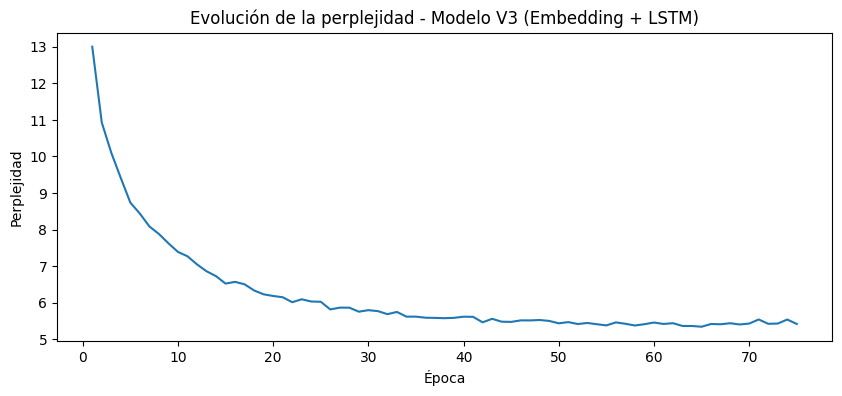

In [29]:
# Gráfico de perplejidad V3
epoch_count_v3 = range(1, len(history_ppl_v3) + 1)
plt.figure(figsize=(10, 4))
sns.lineplot(x=list(epoch_count_v3), y=history_ppl_v3)
plt.xlabel('Época')
plt.ylabel('Perplejidad')
plt.title('Evolución de la perplejidad - Modelo V3 (Embedding + LSTM)')
plt.show()

In [30]:
# Cargar el mejor modelo V3
model_v3 = keras.models.load_model('my_model_v3.keras')

### Paso 5: Generación de secuencias

#### Greedy search con temperatura

Se genera texto carácter a carácter usando muestreo con temperatura y opcionalmente top-k sampling:
- Temperatura baja (0.3-0.5): distribución más "aguda", texto más conservador pero coherente.
- Temperatura = 1.0: distribución original del modelo.
- Temperatura alta (>1.0): distribución más "plana", mayor diversidad pero riesgo de incoherencia.
- Top-k: restringe el muestreo a los k caracteres más probables, eliminando caracteres improbables que generan palabras inexistentes.

In [32]:
def generate_seq_v3(model, seed_text, max_length, n_chars, temperature=0.7, top_k=0):
    """
    Genera secuencia carácter a carácter con muestreo por temperatura.
    Adaptado para modelo con return_sequences=False.
    top_k > 0: solo muestrea de los k caracteres más probables (reduce palabras inexistentes).
    """
    output_text = seed_text.lower()

    for _ in range(n_chars):
        encoded = [char2idx_v3.get(ch, 0) for ch in output_text]
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

        # return_sequences=False → output shape (1, vocab_size)
        preds = model.predict(encoded, verbose=0)[0]

        # Aplicar temperatura
        preds = np.log(preds + 1e-10) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        if top_k > 0:
            # Top-k: solo considerar los k caracteres más probables
            top_indices = np.argsort(preds)[-top_k:]
            top_probs = preds[top_indices]
            top_probs = top_probs / np.sum(top_probs)
            y_hat = np.random.choice(top_indices, p=top_probs)
        else:
            y_hat = np.random.choice(len(preds), p=preds)

        char = idx2char_v3.get(y_hat, '')
        output_text += char

    return output_text

In [34]:
# Generación V3 con diferentes temperaturas y top-k
print("=" * 80)
print("GENERACIÓN V3 - Modelo con Embedding + LSTM + texto limpio")
print("=" * 80)

input_text_v3 = 'el principito'

# Sin top-k (sampling completo)
print("\n>>> Sin top-k (sampling de toda la distribución):")
for temp in [0.3, 0.5, 0.7, 1.0]:
    print(f"\n--- Temperatura = {temp} ---")
    print(generate_seq_v3(model_v3, input_text_v3, max_length=max_context_size_v3, n_chars=200, temperature=temp))

# Con top-k=5
print("\n" + "=" * 80)
print(">>> Con top-k=5 (solo los 5 chars más probables):")
for temp in [0.3, 0.5, 0.7, 1.0]:
    print(f"\n--- Temperatura = {temp}, top_k=5 ---")
    print(generate_seq_v3(model_v3, input_text_v3, max_length=max_context_size_v3, n_chars=200, temperature=temp, top_k=5))

GENERACIÓN V3 - Modelo con Embedding + LSTM + texto limpio

>>> Sin top-k (sampling de toda la distribución):

--- Temperatura = 0.3 ---
el principito de decía mi preguntó el principito.
la vienes que se amigo de la puede de la cansado de la raro de de una ver los dores está se contento de la flor muy dibujo el principito por un poco de la archanar

--- Temperatura = 0.5 ---
el principito desestrada.
¡buenos días! siguió mi serpiente y no eso no tengo a será —dijo el principito es fue interrimpido gusta muy rey de dicho mi preguntó el principito.
el principito duadperprinte el princip

--- Temperatura = 0.7 ---
el principito duóoban nuncaba oldana en algo, para un hombre más que un casa para de minos había godo melancon noche.
¿sobre su parecería —dijo el principito se tras más flores para tienente y no ha hico día del r

--- Temperatura = 1.0 ---
el principito riguno de úticar, para una flor pero!
y tengo arreto a fela fentralla, las ellances volví cuando en las ridas poderlos buenas 

In [35]:
# Probar con semillas del libro (V3) - usando top_k=5 y temp baja
print("=" * 80)
for seed in ['lo esencial es invisible', 'las personas mayores', 'domestícame']:
    print(f"\nSeed: '{seed}'")
    print(generate_seq_v3(model_v3, seed, max_length=max_context_size_v3, n_chars=200, temperature=0.4, top_k=5))
    print("-" * 80)


Seed: 'lo esencial es invisible'
lo esencial es invisible de su preguntó el principito se dijo el principito se preguntó la consegué a la consiguiente a su preguntó el principito se dijo el principito de una flor muy parecer de la respondió el principito no
--------------------------------------------------------------------------------

Seed: 'las personas mayores'
las personas mayores de una flor de sol venidos de las flores? —preguntó el principito de dijo el principito—.
¡buenos días! —dijo el principito no tengo a la cuando está de la pueda de una verdadera de la racio el princ
--------------------------------------------------------------------------------

Seed: 'domestícame'
domestícamente estaba su preguntar que no se decía de una planeta de una preguntado el principito se consiguió
la rigo en muy cordero se puede de una flor de una marcha de la respondió el principito de la rago d
--------------------------------------------------------------------------------


### Paso 6: Beam search determinístico y estocástico

Beam search
- Determinístico (mode='det'): selecciona los beams con mayor probabilidad acumulada.
- Estocástico(mode='sto'): muestrea entre candidatos según su probabilidad, controlado por temperatura.

In [36]:
from scipy.special import softmax

def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    """Selecciona candidatos para el beam search."""
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1E-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large / temp))
    else:
        raise ValueError(f'Wrong selection mode. {mode} was given.')

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T),
        axis=1
    )
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)

def encode_v3(text, max_length=max_context_size_v3):
    encoded = [char2idx_v3.get(ch, 0) for ch in text.lower()]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded

def decode_v3(seq):
    return ''.join([idx2char_v3.get(ch, '') for ch in seq])

def beam_search_v3(model, num_beams, num_words, input_text, temp=1, mode='det'):
    encoded = encode_v3(input_text)
    # return_sequences=False → output shape (1, vocab_size)
    y_hat = model.predict(encoded, verbose=0)[0]
    vs = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vs, history_probs, history_tokens, temp, mode
    )

    for i in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            y_hat = model.predict(input_update, verbose=0)[0]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vs, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input_text) + num_words):]

In [37]:
# Beam search V3 - determinístico
print("Beam search determinístico (V3):")
salidas_v3_det = beam_search_v3(model_v3, num_beams=5, num_words=80, input_text="el principito", mode='det')
print(decode_v3(salidas_v3_det[0]))

print("\n" + "=" * 80)

# Beam search V3 - estocástico con diferentes temperaturas
for temp in [0.5, 0.8, 1.2]:
    salidas_v3_sto = beam_search_v3(model_v3, num_beams=5, num_words=80, input_text="el principito", temp=temp, mode='sto')
    print(f"\nBeam search estocástico, temperatura = {temp}:")
    print(decode_v3(salidas_v3_sto[0]))
    print("-" * 80)

Beam search determinístico (V3):
el principito.
el principito se respondió el principito.
¡buenos días! —respondió el principi


Beam search estocástico, temperatura = 0.5:
el principito no tengo de que la respondió el principito se respondió el principito después d
--------------------------------------------------------------------------------

Beam search estocástico, temperatura = 0.8:
el principito no por la una hacer que la hiciera que se estrellas de la flor —dijo el princip
--------------------------------------------------------------------------------

Beam search estocástico, temperatura = 1.2:
el principito que había de que se hacer una razonable, yo había noche había una flor comprend
--------------------------------------------------------------------------------


---

## Registro de versiones y conclusiones

### Fase 1: Exploración inicial con OHE (descartada)

Se probaron 3 arquitecturas RNN con representación One-Hot Encoding sobre el texto crudo:

| Versión | Arquitectura | Representación | Decodificación | Resultado |
|---|---|---|---|---|
| **V1** | SimpleRNN 2×256 | OHE | Greedy (argmax) | Loops repetitivos ("el el el el...") |
| **V2** | LSTM 2×256 | OHE | Sampling temp. | Texto incoherente, caracteres aleatorios |
| **V3** | GRU 2×256 | OHE | Sampling temp. | Similar a V2, sin mejora significativa |

**Problemas identificados**:
- Texto sucio: números de página, metadata editorial, numeración romana de capítulos, puntuación inconsistente (puntos suspensivos, guiones de diálogo, dos puntos).
- OHE genera vectores dispersos sin capturar relaciones entre caracteres similares.
- Modelos sobredimensionados (~633K parámetros) para un corpus de ~80K caracteres → overfitting severo.
- return_sequences=True en todas las capas RNN: el modelo entrenaba prediciendo 120 caracteres por muestra pero en generación solo se usaba la última posición → desalineamiento entrenamiento/inferencia.
- Secuencias con stride=1 generaban ~55K muestras casi idénticas (cada par difiere en 1 char), inflando el dataset sin agregar información real.

### Fase 2: Modelo con Embedding + GRU + texto limpio

Se limpió exhaustivamente el texto (eliminar metadata, números de página, capítulos romanos, normalizar puntuación) y se cambió a Embedding + GRU:

| Aspecto | Detalle |
|---|---|
| **Arquitectura** | GRU 2×128, `return_sequences=True` en ambas capas |
| **Representación** | Embedding(32), índices desde 0 |
| **Target** | Secuencia completa desplazada (y shape = `(N, 120)`) |
| **Datos** | Stride=1, ~55K secuencias casi idénticas |
| **Optimizador** | rmsprop + ReduceLROnPlateau |
| **Épocas** | 50 |
| **Perplejidad** | ~5.3 (aún bajando al cortar el entrenamiento) |

**Resultado**: leve mejora respecto a Fase 1. El texto generado tiene estructura de español (espacios, puntos) pero produce muchas palabras inexistentes. La perplejidad no convergió en 50 épocas.

**Diagnóstico**: el desalineamiento `return_sequences=True` / generación con `preds[0, -1, :]` desperdiciaba la capacidad del modelo. El stride=1 no aportaba diversidad real.

### Fase 3: Modelo final

Se reestructuró:

| Aspecto | Detalle |
|---|---|
| **Arquitectura** | LSTM 2×64 (`return_sequences=True/False`) + Dense(32, relu) |
| **Representación** | Embedding entrenable (dim=50, índice 0=padding) |
| **Target** | Siguiente carácter (y shape = `(N,)`) — alineado con generación |
| **Datos** | Split en oraciones + sub-secuencias prefijo (108.640 secuencias) |
| **Optimizador** | rmsprop + ReduceLROnPlateau |
| **Regularización** | Dropout(0.2) entre capas LSTM |
| **Contexto** | 60 caracteres |
| **Parámetros** | 69.275 |
| **Vocabulario** | 56 caracteres |
| **Decodificación** | Sampling con temperatura + top-k + beam search (det/sto) |
| **Épocas** | 75 (patience=10, early stopping) |

#### Resultados de perplejidad

| Métrica | Valor |
|---|---|
| PPL inicial | 13.00 |
| **PPL mínima** | **5.34** (época 65) |
| PPL final | 5.42 |
| Últimas 5 PPL | 5.54, 5.42, 5.43, 5.54, 5.42 |

La perplejidad convergió a ~5.4, oscilando sin mejora significativa en las últimas 10 épocas. El early stopping detuvo correctamente el entrenamiento en la época 75.

#### Resultados de generación

**Sampling con temperatura (sin top-k):**

| Temp | Texto generado |
|---|---|
| 0.3 | *"el principito en una flor de como el principito no tengo de una marcha de la rago de la serpiente..."* — Estructura gramatical razonable pero repetitivo y con palabras inventadas ("rago"). |
| 0.7 | *"el principito la cabero, está me surguiente—. ¿el principito recidó una flor..."* — Más diverso pero más palabras inexistentes ("cabero", "surguiente", "recidó"). |
| 1.0 | *"el principito planea ésta de contesto una elefante dal la habiero..."* — Alta diversidad, muchas palabras inventadas ("habiero", "ocuella"). |

**Sampling con top-k=5:**

| Temp | Texto generado |
|---|---|
| 0.3 | *"el principito se dijo el principito no se preguntó el principito son más estrellas..."* — Más coherente, palabras reales, pero muy repetitivo ("el principito" aparece 3 veces). |
| 0.7 | *"el principito si mis primeran el principito no tengo de la flor..."* — Buen balance, algunas palabras inventadas ("primeran", "amantraro"). |

**Semillas del libro (temp=0.4, top-k=5):**

| Semilla | Texto generado |
|---|---|
| "lo esencial es invisible" | *"...más decía de la riguera de una flor de algo en una razonado de serpiente el principito se contentó el principito..."* |
| "las personas mayores" | *"...y las rey estaba el principito de la flor mar de la respondió el principito se alver de al principito..."* |

**Beam search:**

| Modo | Texto generado |
|---|---|
| Determinístico | *"el principito. el principito se respondió el principito. ¡buenos días! —dijo el princip..."* — Muy repetitivo (greedy amplificado). |
| Estocástico (temp=0.8) | *"el principito se comprendió el principito. ¡buenos días! —dijo el princip..."* — Similar al determinístico. |

#### Análisis de los resultados

**Aspectos positivos:**
- El modelo captura la estructura del español: espacios entre palabras, puntuación (puntos, comas, signos de exclamación/interrogación, guiones de diálogo).
- Genera entidades y conceptos del libro: "el principito", "la flor", "la serpiente", "el farolero", "las estrellas", "¡buenos días!".
- La perplejidad de ~5.34 es razonable para un modelo char-level con corpus tan pequeño (~60K chars).
- Top-k=5 mejora notablemente la calidad: reduce palabras inexistentes y mantiene vocabulario del libro.

**Limitaciones observadas:**
- Palabras inventadas persisten incluso con top-k: "rago", "cabero", "surguiente", "amantraro", "primeran".
- Repetición excesiva de "el principito" especialmente con temperaturas bajas y beam search. El modelo ha memorizado esta secuencia como la más probable.
- Falta de coherencia semántica: las oraciones tienen estructura sintáctica pero no mantienen un hilo narrativo.
- Beam search no aporta respecto al sampling: produce texto más repetitivo sin ganar coherencia